# Computational Statistical Mechanics - pamuduamarasinghe

1. Degeneracy - 3D harmonic oscillator

In [ ]:
from collections import defaultdict

de ={}

energy_states = defaultdict(list)
n_list = range(10)
E_max  = 7/2

for nx in n_list:
    for ny in n_list:
        for nz in n_list:
            E = nx+ny+nz + 1.5
            energy_states[E].append((nx, ny, nz))
          
            if E <= E_max:
                if E not in de.keys():
                    de[E] = 1
                else:
                    de[E]+=1
energies = sorted(energy_states.keys())

print("Energy levels and their degeneracies")
print(de)

for E in energies[:6]:

    print("\nEnergy =", E)

    states = energy_states[E]

    for state in states:
        print(state)

    print("Degeneracy =", len(states))


Energy levels and their degeneracies
{1.5: 1, 2.5: 3, 3.5: 6}

Energy = 1.5
(0, 0, 0)
Degeneracy = 1

Energy = 2.5
(0, 0, 1)
(0, 1, 0)
(1, 0, 0)
Degeneracy = 3

Energy = 3.5
(0, 0, 2)
(0, 1, 1)
(0, 2, 0)
(1, 0, 1)
(1, 1, 0)
(2, 0, 0)
Degeneracy = 6

Energy = 4.5
(0, 0, 3)
(0, 1, 2)
(0, 2, 1)
(0, 3, 0)
(1, 0, 2)
(1, 1, 1)
(1, 2, 0)
(2, 0, 1)
(2, 1, 0)
(3, 0, 0)
Degeneracy = 10

Energy = 5.5
(0, 0, 4)
(0, 1, 3)
(0, 2, 2)
(0, 3, 1)
(0, 4, 0)
(1, 0, 3)
(1, 1, 2)
(1, 2, 1)
(1, 3, 0)
(2, 0, 2)
(2, 1, 1)
(2, 2, 0)
(3, 0, 1)
(3, 1, 0)
(4, 0, 0)
Degeneracy = 15

Energy = 6.5
(0, 0, 5)
(0, 1, 4)
(0, 2, 3)
(0, 3, 2)
(0, 4, 1)
(0, 5, 0)
(1, 0, 4)
(1, 1, 3)
(1, 2, 2)
(1, 3, 1)
(1, 4, 0)
(2, 0, 3)
(2, 1, 2)
(2, 2, 1)
(2, 3, 0)
(3, 0, 2)
(3, 1, 1)
(3, 2, 0)
(4, 0, 1)
(4, 1, 0)
(5, 0, 0)
Degeneracy = 21


The partition function in the Canonical Ensemble in Bose-Einstein statistics

In [14]:
import numpy as np
import pandas as pd

betas=[0.001,0.01,1]
En =[3.5,4.5,5.5]
Ntotal = [10,50,100,1000,10000]

def degen(E) :
    n = int(E -1.5)
    return (n+1)*(n+2) / 2


rows =[]
for b in betas:
    for E in En:
        gs = degen(E)
        z_theory = gs/ (1-np.exp(-b*E))

        for N in Ntotal:
            z_numeric = sum(
                            gs * np.exp(-b * n * E)
                            for n in range(N + 1)
                        )
            error = abs(z_theory - z_numeric)

            rows.append([
                b,
                E,
                gs,
                N,
                z_numeric,
                z_theory,
                error
            ])

df = pd.DataFrame(
    rows,
    columns=[
        "Beta",
        "Epsilon",
        "Degeneracy",
        "N",
        "Numerical z",
        "Theoretical z",
        "|Difference|"
    ]
)

print(df)

     Beta  Epsilon  Degeneracy      N  Numerical z  Theoretical z  \
0   0.001      3.5         6.0     10    64.859020    1717.287464   
1   0.001      3.5         6.0     50   280.735188    1717.287464   
2   0.001      3.5         6.0    100   511.363570    1717.287464   
3   0.001      3.5         6.0   1000  1665.611061    1717.287464   
4   0.001      3.5         6.0  10000  1717.287464    1717.287464   
5   0.001      4.5        10.0     10   107.563526    2227.225972   
6   0.001      4.5        10.0     50   456.735073    2227.225972   
7   0.001      4.5        10.0    100   813.460274    2227.225972   
8   0.001      4.5        10.0   1000  2202.594817    2227.225972   
9   0.001      4.5        10.0  10000  2227.225972    2227.225972   
10  0.001      5.5        15.0     10   160.548603    2734.779602   
11  0.001      5.5        15.0     50   668.910835    2734.779602   
12  0.001      5.5        15.0    100  1165.603276    2734.779602   
13  0.001      5.5        15.0   1

Degeneracy-Particle in a 3D Box

In [ ]:
from collections import defaultdict

energy_states = defaultdict(list)
n_list = range(10)


hbar =1
m = 1
L = np.pi/np.sqrt(2)

for nx in n_list:
    for ny in n_list:
        for nz in n_list:
            E = (np.pi*hbar/L)**2 * (nx**2 +ny**2 +nz**2) /2*m
            energy_states[E].append((nx, ny, nz))
          
energies = sorted(energy_states.keys())

print("Energy levels and their degeneracies")

for E in energies[:6]:

    print("\nEnergy =", int(E))

    states = energy_states[E]

    for state in states:
        print(state)

    print("Degeneracy =", len(states))


Energy levels and their degeneracies

Energy = 0
(0, 0, 0)
Degeneracy = 1

Energy = 1
(0, 0, 1)
(0, 1, 0)
(1, 0, 0)
Degeneracy = 3

Energy = 2
(0, 1, 1)
(1, 0, 1)
(1, 1, 0)
Degeneracy = 3

Energy = 3
(1, 1, 1)
Degeneracy = 1

Energy = 4
(0, 0, 2)
(0, 2, 0)
(2, 0, 0)
Degeneracy = 3

Energy = 5
(0, 1, 2)
(0, 2, 1)
(1, 0, 2)
(1, 2, 0)
(2, 0, 1)
(2, 1, 0)
Degeneracy = 6


Degeneracy of Hydrogen Atom

Energy levels and degeneracies:
[(-13.6, 2), (-3.4, 8), (-1.511111111111111, 18), (-0.85, 32)]


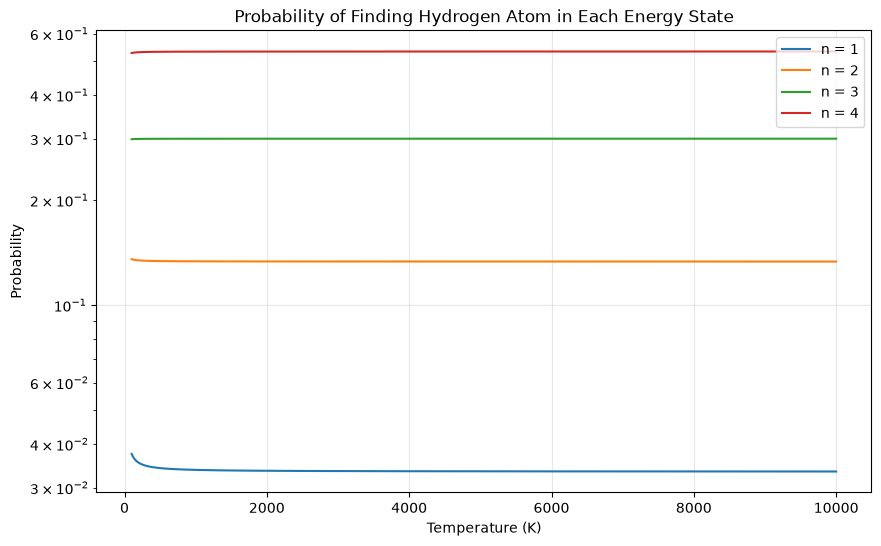

In [45]:
import numpy as np
import matplotlib.pyplot as plt

n_max = 5

def H_degen(n):
    En = []
    gn = []

    if n > 1:
        for i in range(1, n):
            E = -13.6 / i**2
            g = 2 * i**2

            En.append(E)
            gn.append(g)
    else:
        print("Min n = 1")

    return En, gn


En, gn = H_degen(n_max)
En_gn = list(zip(En, gn))

print("Energy levels and degeneracies:")
print(En_gn)


kb = 1.0
T = np.linspace(100, 10000, 1000)

def probability(levels, T):

    beta = 1 / (kb * T)
    Z = 0

    for E, g in levels:
        Z += g * np.exp(-beta * E)

    P = []

    for E, g in levels:
        p = g * np.exp(-beta * E) / Z
        P.append(p)

    return P


P_values = []

for t in T:
    P_values.append(probability(En_gn, t))
P_values = np.array(P_values)



plt.figure(figsize=(10, 6))

for i in range(len(En)):
    plt.plot(T, P_values[:, i], label=f'n = {i+1}')

plt.xlabel('Temperature (K)')
plt.ylabel('Probability')
plt.title('Probability of Finding Hydrogen Atom in Each Energy State')

plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.show()

Bose-Einstein Condensation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def n_MB(N, beta, eps):
    return N / (1 + np.exp(-beta * eps))

def n_BE(N, beta, eps):
    return 1/(np.exp(beta*eps) - 1) + (N + 1)/(1 - np.exp(-(N + 1)*beta*eps))

N = 100
eps = 1
k_B = 1
x = np.linspace(0.1, 10, 500)

n_MB_vals = [n_MB(N, 1/(k_B*T), eps) for T in x]
n_BE_vals = [n_BE(N, 1/(k_B*T), eps) for T in x]


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(x, np.array(n_MB_vals)/np.array(n_BE_vals))
plt.xlabel('k_B T/E')
plt.ylabel('n_MB/n_BE')
plt.title('n_MB/n_BE vs k_B T/E')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, np.array(n_BE_vals)/np.array(n_MB_vals))
plt.xlabel('k_B T/E')
plt.ylabel('n_BE/n_MB')
plt.title('n_BE/n_MB vs k_B T/E')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


print("\nPart b")
print("k_B T/E | n_MB/N (%)")
for kBT in [1/4, 1/2, 1, 2, 4]:
    beta = 1/kBT
    print(f"{kBT:8.2f} | {n_MB(N, beta, eps)/N*100:15.2f}%")

print("\nPart c")
print("k_B T/E | n_BE/N (%)")
for kBT in [1/4, 1/2, 1, 2, 4]:
    beta = 1/kBT
    print(f"{kBT:8.2f} | {n_BE(N, beta, eps)/N*100:15.2f}%")

print("\nPart d")
for kBT in [10, 100, 1000]:
    beta = 1/kBT
    ratio = n_BE(N, beta, eps)/n_MB(N, beta, eps)
    print(f"k_B T/E = {kBT:4.0f}: n_BE/n_MB = {ratio:.6f}")